In [ ]:
#KNN --> K-Nearest Neighbors --> supervised Learning Method
# Used for classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv("/content/ds_income_class.csv")

In [ ]:
num_cols_list = df.select_dtypes(include="number").columns.tolist() #Numerical Features
cat_cols_list = df.select_dtypes(exclude="number").columns.tolist() #Categorical Features


print(num_cols_list)
print(cat_cols_list)

for col in cat_cols_list:
    df[col] = df[col].str.strip()

cat_cols_list.remove("salary")

['age', 'fnlwgt', 'education_no_of_years', 'capital_gain', 'capital_loss', 'working_hours_per_week']
['workclass', 'education', 'marital_status', 'occupation', 'race', 'sex', 'native_contienent', 'salary']


In [ ]:
y = (df["salary"] == ">50K").astype(int)
#print(y.head(10))

X = df.drop("salary", axis=1)
#print(X.head(10))

In [ ]:
# StandardScaling and OneHotEncoding
preprocess = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), num_cols_list),
        ("cat", OneHotEncoder(), cat_cols_list)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, RocCurveDisplay, PrecisionRecallDisplay

k = 5
knn5 = KNeighborsClassifier(n_neighbors=k)

knn_pipeline = Pipeline (
    steps = [
        ("preprocess", preprocess),
        ("knn5", knn5)
    ]
)

knn_pipeline.fit(X_train, y_train)
y_pred_knn5 = knn_pipeline.predict(X_test)
print("Predictions: ", y_pred_knn5[:10])

print(classification_report(y_test, y_pred_knn5))

Predictions:  [0 0 0 0 0 1 0 0 1 0]
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      4939
           1       0.66      0.62      0.64      1568

    accuracy                           0.83      6507
   macro avg       0.77      0.76      0.77      6507
weighted avg       0.83      0.83      0.83      6507



Performance is not good, because it is either because the data is imbalanced, or we have picked the wrong K value.

In [ ]:
from sklearn.metrics import average_precision_score

y_pred_knn5_prob = knn_pipeline.predict_proba(X_test)[:,1]

pr_auc = average_precision_score(y_test, y_pred_knn5_prob)
print("AUC-PR Score: ", pr_auc)

AUC-PR Score:  0.6449197122768323


In [ ]:
# Elbow method with KFold Cross Validation to find the best K value for KNN
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_values = list(range(1,51,2))
all_k_metrics = []


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn_pipeline = Pipeline (
        steps = [
            ("preprocess", preprocess),
            ("knn", knn)
        ]
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=cv, scoring="f1")
    all_k_metrics.append([k,cv_scores.mean(),cv_scores.std()])

k_metric_df = pd.DataFrame(all_k_metrics,columns=["K","F1-Score(Avg)","F1-Score(std)"])
print(k_metric_df)


     K  F1-Score(Avg)  F1-Score(std)
0    1       0.582703       0.004914
1    3       0.612691       0.006632
2    5       0.631608       0.004928
3    7       0.636508       0.004478
4    9       0.635811       0.004097
5   11       0.637375       0.005432
6   13       0.642060       0.004601
7   15       0.640250       0.004241
8   17       0.640202       0.004021
9   19       0.641354       0.004932
10  21       0.636715       0.005445
11  23       0.635920       0.006947
12  25       0.638958       0.008641
13  27       0.638227       0.007651
14  29       0.638413       0.008253
15  31       0.636752       0.004880
16  33       0.634752       0.005135
17  35       0.635356       0.004740
18  37       0.634386       0.006219
19  39       0.635230       0.007529
20  41       0.633281       0.006230
21  43       0.632078       0.006932
22  45       0.632989       0.004954
23  47       0.632791       0.006383
24  49       0.631581       0.007038


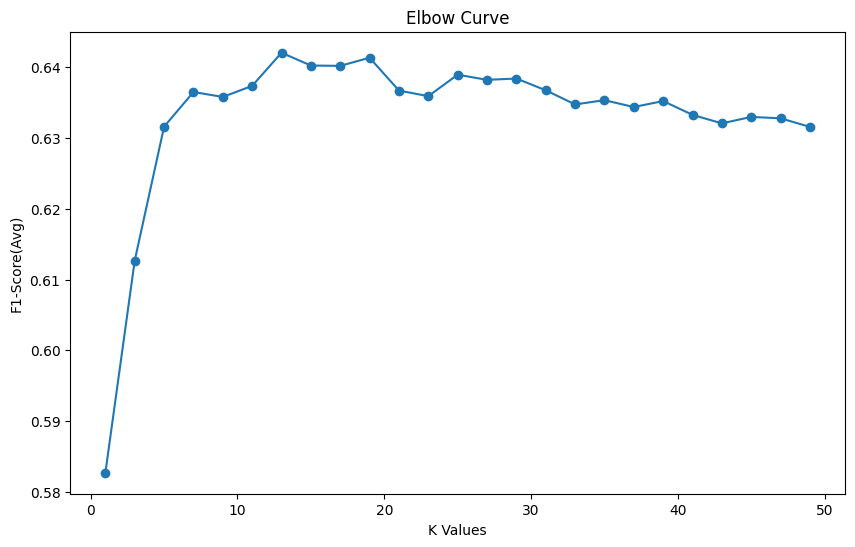

In [ ]:
plt.figure(figsize=(10,6))
plt.title("Elbow Curve")
plt.plot(k_values,k_metric_df["F1-Score(Avg)"], marker="o")
plt.xlabel("K Values")
plt.ylabel("F1-Score(Avg)")
plt.show()

According to the graph here, the best K value would be 7, as the graph plateaus after it. Making 7 the most ideal with the highest f1 score.